# Entrenamiento de Redes Neuronales Profundas

Con DL nos referimos a ANN de más diez capas ocultas, cada capa puede tener cientos de neuronas.

## Dificultad en la implementación de DL

* Problemas con el gradiente de la red que puede crecer muy rápido o muy lento.
* Para el entrenamiento de DL se necesita una gran cantidad de datos.
* El entrenamiento puede ser extremedamiento lento.
* Hay riesgo de sobre entrenamiento, si no hay suficientes datos, o si los datos tienen mucho ruido.



## Problemas con el Gradiente

Desvanecimiento del gradiente por culpa de la saturación de la funciín de activación Sigmoid

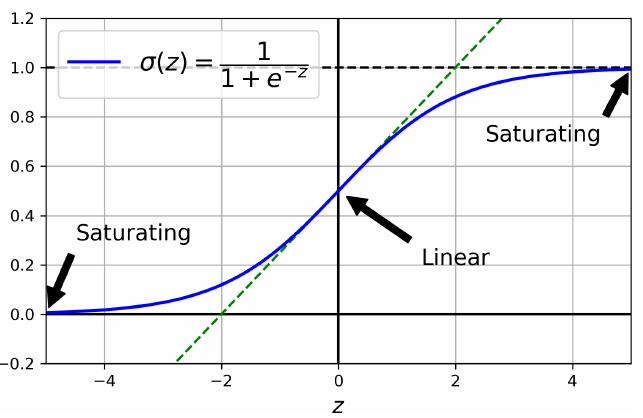

Parámetros de inicialización por cada tipo de función de activación
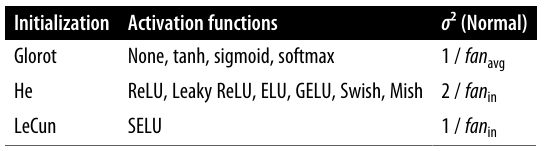

## Inicialización de Glorot

Por defecto Keras usa inicialización de Glorot

In [2]:
import tensorflow as tf
dense = tf.keras.layers.Dense(50, activation="relu", kernel_initializer="he_normal")

## Inicialización de Xavier and He

Usando VarianceScaling se puede utilizar el inicializador de He.

In [3]:
he_avg_init = tf.keras.initializers.VarianceScaling(scale=2., mode="fan_avg", distribution="uniform")
dense = tf.keras.layers.Dense(50, activation="sigmoid", kernel_initializer=he_avg_init)

## Mejores funciones de activación

 Los problemas con la función de activición se debe al uso de la funnción Sigmoid. La función Sigmoid es la usada en las redes neuronales biológicas.

### Función de activación Leaky ReLU

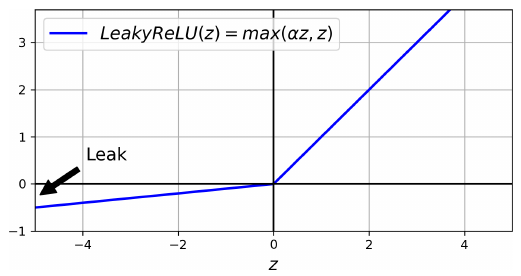


In [4]:
#leaky_relu = tf.keras.layers.LeakyReLU(alpha=0.2) # defaults to alpha=0.3
leaky_relu = tf.keras.layers.LeakyReLU(negative_slope=0.2) # defaults to alpha=0.3
dense = tf.keras.layers.Dense(50, activation=leaky_relu, kernel_initializer="he_normal")

Se otra forma de usar leaky relu, es como una capa de la red

In [5]:
model = tf.keras.models.Sequential([
    # [...]  # more layers
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # no activation
    tf.keras.layers.LeakyReLU(alpha=0.2),  # activation as a separate layer
    # [...]  # more layers
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


### Funciones de activación ELU SELU

La función de activación *Exponential Linear Unit* (ELU), tiene un rendimiento superior a la ReLU

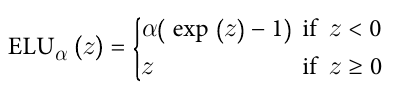


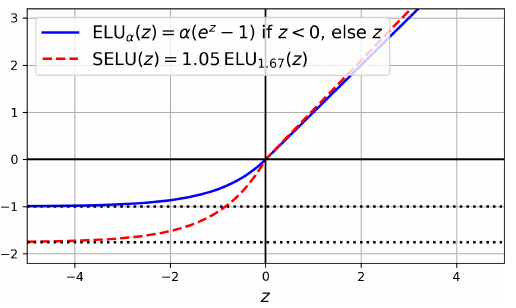

La función ELU es más lenta de computar que la ReLU, pero hace que el modelo entrene más rápidamente.

## Función de activación SELU

* SELU mostró excelentes resultados en una gran variedad de problemas
* En Keras se puede usar SELU directmanete
* Se usa como inicialización la de Lecun

In [6]:
dense = tf.keras.layers.Dense(50, activation="selu", kernel_initializer="lecun_normal")

## Ejemplo de una red auto regularizada con función de activación SELU

* Se crea una red con 100 capas ocultas
* Se quiere predecir piezas de vestir del conjunto de datos Fashion MNIST.

In [7]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

* Se descarga el conjunto de datos Fashion MNIST
* Se preparan los conjuntos de datos para el entrenamiento y la validación

In [9]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]
X_train, X_valid, X_test = X_train / 255, X_valid / 255, X_test / 255

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


* Se crea un vector con las clases de del conjunto de datos

In [10]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

* Se hace una normalización de los datos

In [11]:
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

* Se entrena la red para obtener el modelo

In [12]:
history = model.fit(X_train_scaled, y_train, epochs=5, validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.4910 - loss: 1.3468 - val_accuracy: 0.6400 - val_loss: 0.9651
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.7030 - loss: 0.8222 - val_accuracy: 0.7384 - val_loss: 0.7314
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.7573 - loss: 0.6714 - val_accuracy: 0.7642 - val_loss: 0.6400
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.7891 - loss: 0.5800 - val_accuracy: 0.7812 - val_loss: 0.5990
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.8118 - loss: 0.5291 - val_accuracy: 0.8058 - val_loss: 0.5379


## Ejemplo de desvanecimiento del gradiente

Creamos una red profunda como la anterior, pero usamos la función de activación ReLU, en lugar de SELU

In [13]:
tf.random.set_seed(42)

In [14]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
for layer in range(100):
    model.add(tf.keras.layers.Dense(100, activation="relu",
                                    kernel_initializer="he_normal"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [15]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics=["accuracy"])

* Se entrena el modelo
* Se puede obsevar que los valores de  exactitud (accuracy) son menores que el modelo anterior
* Se muestra que los valores de pérdida (loss) aumentan

In [16]:
history = model.fit(X_train_scaled, y_train, epochs=5, validation_data=(X_valid_scaled, y_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.2580 - loss: 1.8539 - val_accuracy: 0.3576 - val_loss: 1.5005
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.4569 - loss: 1.2929 - val_accuracy: 0.3966 - val_loss: 1.4452
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.5889 - loss: 1.0253 - val_accuracy: 0.6780 - val_loss: 0.8515
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.6674 - loss: 0.8354 - val_accuracy: 0.6898 - val_loss: 0.8074
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.6332 - loss: 0.8900 - val_accuracy: 0.6828 - val_loss: 0.8218


### Funciones de activación GELU, Swish, and Mish

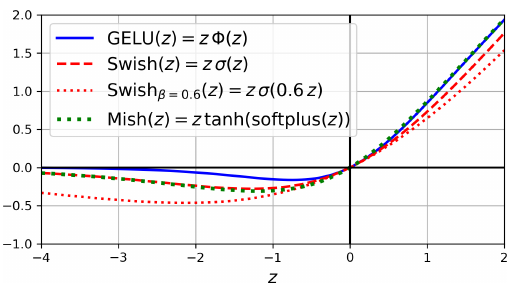

* Φ es la función de distribución acumulativa (FDA) gaussiana estándar: Φ(z) corresponde a la probabilidad de que un valor muestreado aleatoriamente de una distribución normal con media 0 y varianza 1 sea menor que z.
* σ es la función sigmoed.

### ¿Cuál función de activación a usar?

* Para tareas simples leaky ReLU
* Para problemas complejas Swish
* Para Deep MLP SELU

Keras soporta activation="gelu" y activation="swish"

## Normalización por lotes

Aunque la inicialización He junto con Leaky ReLU (o cualquiera de sus variantes) puede reducir los problemas de gradientes evanescentes/explosivos al inicio del entrenamiento, no garantiza que no vuelvan a aparecer más adelante

El objetivo de la Normalización por lotes es hacer que el proceso de entrenamiento sea más rápido y estable normalizando las entradas a cada capa de la red.
Su objetivo es agilizar y estabilizar el proceso de entrenamiento normalizando las entradas de cada capa de la red.

Pasos clave:
* Normalización: Las entradas de cada capa se ajustan para tener una media de cero y una desviación estándar de uno. Esto se logra calculando la media y la varianza del mini-lote actual.

* Escalado y desplazamiento: Tras la normalización, las salidas se escalan y desplazan mediante parámetros entrenables, lo que permite que la red se adapte a diferentes distribuciones.

### Normalización por lotes usando Keras


In [17]:
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=[28, 28]),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dense(300, activation="relu",
kernel_initializer="he_normal"),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dense(100, activation="relu",
kernel_initializer="he_normal"),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dense(10, activation="softmax")
])

In [18]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_207 (Dense)               │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_208 (Dense)               │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_209 (Dense)               │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,346 (1.04 MB)

 Trainable params: 268,978 (1.03 MB)

 Non-trainable params: 2,368 (9.25 KB)

## Ejemplo de la aplicación de un modelo con Normalización

In [34]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

* Se compila el modelo

In [35]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

* Se entrena el modelo

In [37]:
model.fit(X_train, y_train, epochs=3, validation_data=(X_valid, y_valid))

Epoch 1/3
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7852 - loss: 0.6009 - val_accuracy: 0.8310 - val_loss: 0.4673
Epoch 2/3
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7996 - loss: 0.5601 - val_accuracy: 0.8388 - val_loss: 0.4402
Epoch 3/3
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8086 - loss: 0.5331 - val_accuracy: 0.8438 - val_loss: 0.4283


Los autores de la Normalización por lotes, recomienda aplicarla antes de la función de activación.

In [38]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

Se muestra el modelo con normalización por lotes antes de de la función de activación

In [19]:
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=[28, 28]),
tf.keras.layers.Dense(300, kernel_initializer="he_normal", use_bias=False),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Activation("relu"),
tf.keras.layers.Dense(100, kernel_initializer="he_normal", use_bias=False),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Activation("relu"),
tf.keras.layers.Dense(10, activation="softmax")
])

* Se compila el modelo

In [39]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

* Se entrena el modelo

In [41]:
model.fit(X_train, y_train, epochs=3, validation_data=(X_valid, y_valid))

Epoch 1/3
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8232 - loss: 0.4882 - val_accuracy: 0.8552 - val_loss: 0.3992
Epoch 2/3
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8273 - loss: 0.4765 - val_accuracy: 0.8578 - val_loss: 0.3922
Epoch 3/3
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8321 - loss: 0.4684 - val_accuracy: 0.8584 - val_loss: 0.3859


## Gradient Clipping

* Es una técnica para minimizar la explosión del gradiente.
* Se hace que el valor del gradiente no sobrepase un umbral.

In [42]:
optimizer = tf.keras.optimizers.SGD(clipvalue=1.0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer)

## Optimizadores más rápidos

* Emtrenar una red profunda puede tomar mucho tiempo.
* Hemos visto tres estrategias que mejoran el entrenamiento:
  1.   Inicialización de los pesos.
  2.   Funciones de activación mejoradas.
  3.   Normalización por lotes.
* Otra forma de acelerar el entranamiento es usando un optimizador más rápido que el optimizador de descenso de gradiente convencional.
* Otros posibles optimizadores: momentum, gradiente acelerado de Nesterov, AdaGrad, RMSProp y Adam.

   

Se programan unas funciones para probar los optimizadores

In [44]:
def build_model(seed=42):
    tf.random.set_seed(seed)
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=[28, 28]),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(100, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

Esta función recibe un obtimizador, para construir y entrenar un modelo con este optimizador

In [45]:
def build_and_train_model(optimizer):
    model = build_model()
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                  metrics=["accuracy"])
    return model.fit(X_train, y_train, epochs=10,
                     validation_data=(X_valid, y_valid))

Como base se tiene un modelo que usa como optimizador SGD

In [46]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)

Se entrena el modelo que usa el optimizador SGD

In [47]:
history_sgd = build_and_train_model(optimizer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5840 - loss: 1.3892 - val_accuracy: 0.7148 - val_loss: 0.8739
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7335 - loss: 0.7771 - val_accuracy: 0.7672 - val_loss: 0.6866
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7759 - loss: 0.6566 - val_accuracy: 0.7940 - val_loss: 0.6086
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7990 - loss: 0.5953 - val_accuracy: 0.8066 - val_loss: 0.5642
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8114 - loss: 0.5567 - val_accuracy: 0.8146 - val_loss: 0.5350
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8200 - loss: 0.5298 - val_accuracy: 0.8250 - val_loss: 0.5144
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8252 - loss: 0.5097 - val_accuracy: 0.8286 - val_loss: 0.4992
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8305 - loss: 0.4937 - 

### Momentum

Este optimizador trabaja como una bola de boliche viajando por una pendiente suave sobre una superficie lisa: comenzará lentamente, pero rápidamente ganará impulso hasta alcanzar la velocidad máxima.

In [49]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)

Se prueba el optimizador Momentum

In [50]:
history_momentum = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7715 - loss: 0.6684 - val_accuracy: 0.8198 - val_loss: 0.5028
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8362 - loss: 0.4678 - val_accuracy: 0.8262 - val_loss: 0.4701
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8513 - loss: 0.4243 - val_accuracy: 0.8368 - val_loss: 0.4403
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8603 - loss: 0.3965 - val_accuracy: 0.8448 - val_loss: 0.4188
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8660 - loss: 0.3765 - val_accuracy: 0.8510 - val_loss: 0.4057
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8713 - loss: 0.3611 - val_accuracy: 0.8510 - val_loss: 0.4026
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8755 - loss: 0.3481 - val_accuracy: 0.8520 - val_loss: 0.3990
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8797 - loss: 0.3365 - 

### Gradiente acelerado de Nesterov

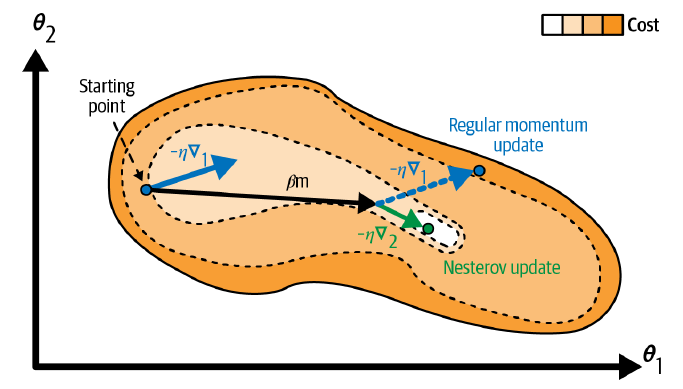

In [54]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9, nesterov=True)

Se prueba el optimizador de Nesterov

In [55]:
history_nesterov = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7613 - loss: 0.7088 - val_accuracy: 0.8208 - val_loss: 0.4965
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8372 - loss: 0.4652 - val_accuracy: 0.8340 - val_loss: 0.4501
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8523 - loss: 0.4218 - val_accuracy: 0.8448 - val_loss: 0.4220
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8615 - loss: 0.3953 - val_accuracy: 0.8492 - val_loss: 0.4080
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8678 - loss: 0.3756 - val_accuracy: 0.8554 - val_loss: 0.3937
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8729 - loss: 0.3597 - val_accuracy: 0.8582 - val_loss: 0.3843
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8776 - loss: 0.3461 - val_accuracy: 0.8590 - val_loss: 0.3769
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8807 - loss: 0.3348 - 

### AdaGrad

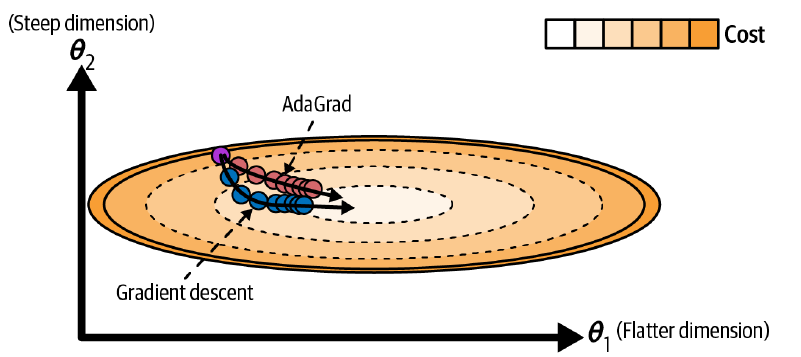

* Trabaja bien en problemas simples.
* Pero en problemas complejos y en redes profundas, opera de forma muy lenta y es díficil alcanzar un óptimo global.
* No se debería usar en redes profundas.
* Se menciona como ejemplo y porque ha sido mejorado.

In [56]:
optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.001)

Se prueba el optimizador AdaGrad

In [57]:
history_adagrad = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6685 - loss: 1.0240 - val_accuracy: 0.7686 - val_loss: 0.6954
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7842 - loss: 0.6472 - val_accuracy: 0.8006 - val_loss: 0.5921
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8085 - loss: 0.5751 - val_accuracy: 0.8158 - val_loss: 0.5451
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8208 - loss: 0.5368 - val_accuracy: 0.8244 - val_loss: 0.5171
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8279 - loss: 0.5125 - val_accuracy: 0.8270 - val_loss: 0.4983
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8323 - loss: 0.4952 - val_accuracy: 0.8314 - val_loss: 0.4844
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8363 - loss: 0.4821 - val_accuracy: 0.8342 - val_loss: 0.4736
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8393 - loss: 0.4716 - 

### RMSProp
 * Es una mejora de AdaGraph, que permite que se converga al valor óptimo.
 * Este optimizador se puede usar en redes profundas

In [58]:
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

Se prueba el optimizador RMSProp

In [59]:
history_rmsprop = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8124 - loss: 0.5165 - val_accuracy: 0.8314 - val_loss: 0.4314
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8602 - loss: 0.3880 - val_accuracy: 0.8496 - val_loss: 0.4180
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8718 - loss: 0.3589 - val_accuracy: 0.8568 - val_loss: 0.4076
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8781 - loss: 0.3474 - val_accuracy: 0.8458 - val_loss: 0.4606
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8801 - loss: 0.3401 - val_accuracy: 0.8536 - val_loss: 0.4598
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8832 - loss: 0.3384 - val_accuracy: 0.8558 - val_loss: 0.4139
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8849 - loss: 0.3344 - val_accuracy: 0.8516 - val_loss: 0.5150
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8866 - loss: 0.3317 -

### Adam

* Combina las ideas del optimizador momentum y RMSProp.
* Es un algoritmo adaptativo, que modifca su tasa de aprendizaje.

In [60]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

Prueba del optimizador Adam

In [61]:
history_adam = build_and_train_model(optimizer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8196 - loss: 0.5058 - val_accuracy: 0.8394 - val_loss: 0.4154
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8625 - loss: 0.3782 - val_accuracy: 0.8508 - val_loss: 0.3926
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8757 - loss: 0.3378 - val_accuracy: 0.8626 - val_loss: 0.3562
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8837 - loss: 0.3137 - val_accuracy: 0.8574 - val_loss: 0.3782
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8890 - loss: 0.2959 - val_accuracy: 0.8692 - val_loss: 0.3481
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8953 - loss: 0.2771 - val_accuracy: 0.8620 - val_loss: 0.3804
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9009 - loss: 0.2651 - val_accuracy: 0.8674 - val_loss: 0.3806
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9061 - loss: 0.2521 -

### AdaMax

* Modificación del algoritmo de Adam
* El algorimto de Adam se comporta generlamente mejor
* Este algoritmo se usa si AdamMax no funciona bien

In [62]:
optimizer = tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

Se prueba el optimizador AdaMax

In [63]:
history_adamax = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8154 - loss: 0.5289 - val_accuracy: 0.8286 - val_loss: 0.4611
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8605 - loss: 0.3939 - val_accuracy: 0.8488 - val_loss: 0.4063
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8719 - loss: 0.3539 - val_accuracy: 0.8472 - val_loss: 0.3962
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8806 - loss: 0.3280 - val_accuracy: 0.8542 - val_loss: 0.3812
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8870 - loss: 0.3087 - val_accuracy: 0.8538 - val_loss: 0.3814
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8929 - loss: 0.2936 - val_accuracy: 0.8632 - val_loss: 0.3671
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8985 - loss: 0.2799 - val_accuracy: 0.8676 - val_loss: 0.3576
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9026 - loss: 0.2691 - 

### Nadam

In [65]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

Probamos el optimizador Nadam

In [66]:
history_nadam = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8283 - loss: 0.4803 - val_accuracy: 0.8250 - val_loss: 0.4458
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8662 - loss: 0.3670 - val_accuracy: 0.8480 - val_loss: 0.4103
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8793 - loss: 0.3324 - val_accuracy: 0.8628 - val_loss: 0.3744
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8860 - loss: 0.3085 - val_accuracy: 0.8588 - val_loss: 0.3833
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8916 - loss: 0.2929 - val_accuracy: 0.8650 - val_loss: 0.3715
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8965 - loss: 0.2760 - val_accuracy: 0.8578 - val_loss: 0.3831
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9023 - loss: 0.2619 - val_accuracy: 0.8654 - val_loss: 0.3608
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9052 - loss: 0.2514

### AdamW

* Es una variante de Adam que integra una técnica de regularización llamada decaimiento de pesos.
* El decaimiento de pesos reduce el tamaño de los pesos del modelo en cada iteración de entrenamiento multiplicándolos por un factor de decaimiento como 0,9.

In [68]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.004,
    beta_1=0.9,
    beta_2=0.999
)

Probamos el optimizador AdamW

In [69]:
history_adamw = build_and_train_model(optimizer)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8220 - loss: 0.4948 - val_accuracy: 0.8442 - val_loss: 0.4076
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8633 - loss: 0.3718 - val_accuracy: 0.8530 - val_loss: 0.3865
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8761 - loss: 0.3366 - val_accuracy: 0.8586 - val_loss: 0.3866
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8832 - loss: 0.3124 - val_accuracy: 0.8642 - val_loss: 0.3661
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8903 - loss: 0.2941 - val_accuracy: 0.8666 - val_loss: 0.3636
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8953 - loss: 0.2797 - val_accuracy: 0.8758 - val_loss: 0.3464
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8992 - loss: 0.2679 - val_accuracy: 0.8730 - val_loss: 0.3650
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9025 - loss: 0.2569 -

### Comparación de Optimizadores

Leyenda: * Es malo, ** es promedio, *** es bueno

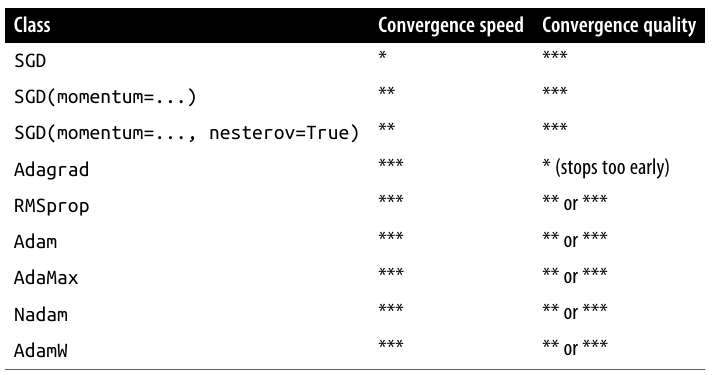

Se hace una gráfica en la que se comparan los optimizadores

In [71]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

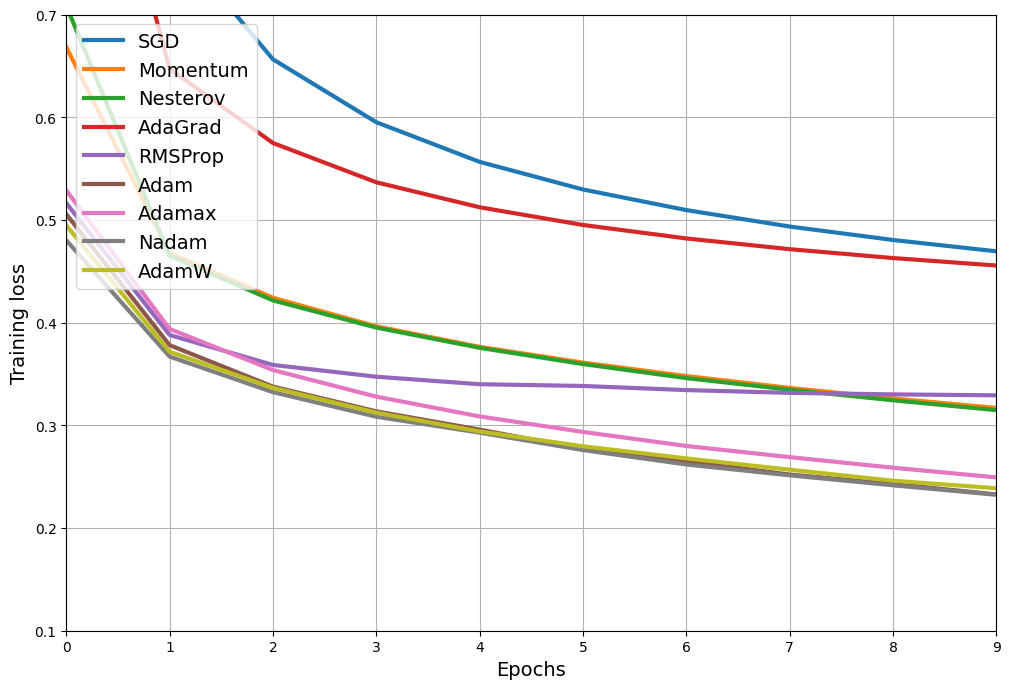

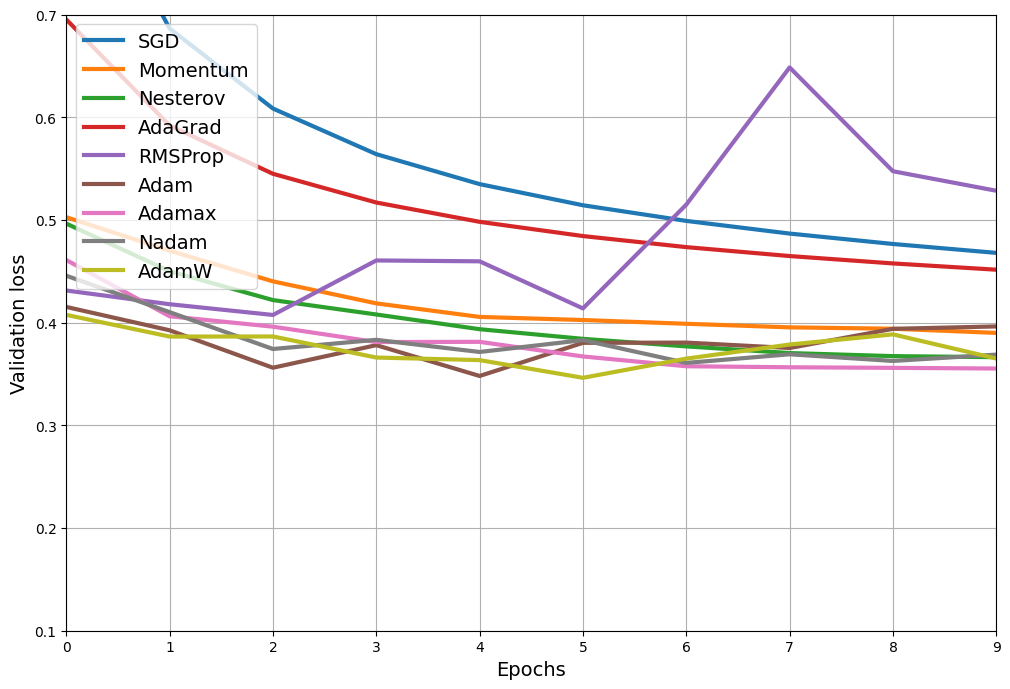

In [72]:
for loss in ("loss", "val_loss"):
    plt.figure(figsize=(12, 8))
    opt_names = "SGD Momentum Nesterov AdaGrad RMSProp Adam Adamax Nadam AdamW"
    for history, opt_name in zip((history_sgd, history_momentum, history_nesterov,
                                  history_adagrad, history_rmsprop, history_adam,
                                  history_adamax, history_nadam, history_adamw),
                                 opt_names.split()):
        plt.plot(history.history[loss], label=f"{opt_name}", linewidth=3)

    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel({"loss": "Training loss", "val_loss": "Validation loss"}[loss])
    plt.legend(loc="upper left")
    plt.axis([0, 9, 0.1, 0.7])
    plt.show()

## Programación de la tasa de aprendizaje

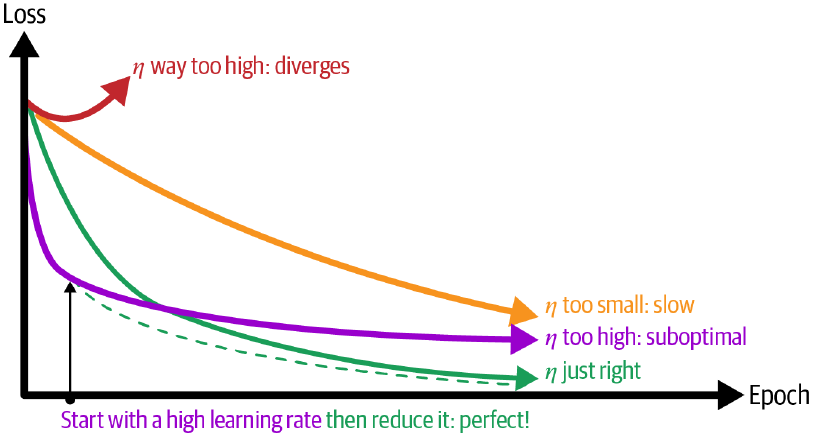

### Power scheduling

In [26]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, decay=1e-4)

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


### Exponential scheduling

In [27]:
def exponential_decay(lr0, s):
  def exponential_decay_fn(epoch):
    return lr0 * 0.1 ** (epoch / s)
  return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

Se crea una programación de la tasa de aprendizaje

In [28]:
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)
# history = model.fit(X_train, y_train, [...], callbacks=[lr_scheduler])

### Performance scheduling

In [29]:
lr0 = 0.01
optimizer = tf.keras.optimizers.SGD(learning_rate=lr0)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
# history = model.fit(X_train, y_train, epochs=n_epochs, validation_data=(X_valid, y_valid), callbacks=[lr_scheduler])

### 1cycle scheduling

* Comienza aumentando la tasa de aprendizaje inicial η0, que crece linealmente hasta η1 a la mitad del entrenamiento.
* Luego, la reduce linealmente hasta η0 nuevamente durante la segunda mitad del entrenamiento
* Finaliza las últimas épocas reduciéndola en varios órdenes de magnitud
* No está implementado en Keras

## Cómo evitar el sobreajuste mediante la regularización

* Las redes profundas permiten tener millones de parámetros
* Esto hace que puedan aprender conjuntos de datos complejos
* La redes profundas son propensas a sobreajustarse al conjunto de entrenamiento.

### Early Stopping

Detiene el entrenamiento cuando hay varias épocas sin mejoras de la red

In [30]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
# history = model.fit([...], callbacks=[checkpoint_cb, early_stopping_cb])

#### Regularización L1 y L2

In [73]:
layer = tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal",
                              kernel_regularizer=tf.keras.regularizers.l2(0.01))

Reinicio de la semilla aleatoria

In [75]:
tf.random.set_seed(42)

Aplicando esta regularización a todas las capas

In [76]:
from functools import partial

RegularizedDense = partial(tf.keras.layers.Dense, activation="relu",
  kernel_initializer="he_normal",
  kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=[28, 28]),
  RegularizedDense(100),
  RegularizedDense(100),
  RegularizedDense(10, activation="softmax")
])

Se compila y entrena el modelo

In [77]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.02)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2,
                    validation_data=(X_valid, y_valid))

Epoch 1/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7749 - loss: 3.1385 - val_accuracy: 0.8270 - val_loss: 1.8649
Epoch 2/2
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8146 - loss: 1.4296 - val_accuracy: 0.8258 - val_loss: 1.1192


### Dropout

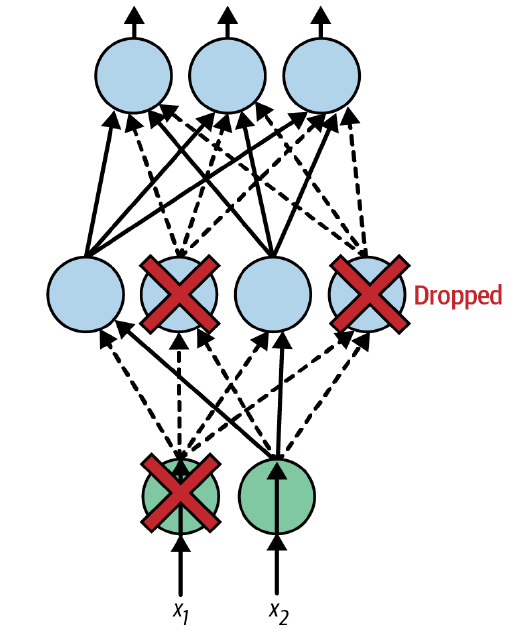

In [78]:
tf.random.set_seed(42)

In [79]:
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=[28, 28]),
  tf.keras.layers.Dropout(rate=0.2),
  tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
  tf.keras.layers.Dropout(rate=0.2),
  tf.keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
  tf.keras.layers.Dropout(rate=0.2),
  tf.keras.layers.Dense(10, activation="softmax")
])


Se crea y se entrena el modelo

In [80]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7520 - loss: 0.6803 - val_accuracy: 0.8218 - val_loss: 0.4727
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8117 - loss: 0.5167 - val_accuracy: 0.8470 - val_loss: 0.4116
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8260 - loss: 0.4751 - val_accuracy: 0.8532 - val_loss: 0.3910
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8333 - loss: 0.4515 - val_accuracy: 0.8512 - val_loss: 0.3931
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8395 - loss: 0.4384 - val_accuracy: 0.8616 - val_loss: 0.3754
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8445 - loss: 0.4245 - val_accuracy: 0.8586 - val_loss: 0.3750
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8466 - loss: 0.4149 - val_accuracy: 0.8676 - val_loss: 0.3601
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8492 - loss: 0.4056 -

* La precisión de entrenamiento parece ser menor que la precisión de validación, pero eso se debe simplemente a que el dropout solo está activo durante el entrenamiento.
* Si evaluamos el modelo en el conjunto de entrenamiento después del entrenamiento (es decir, con el dropout desactivado), obtenemos la precisión de entrenamiento "real", que es ligeramente superior a la precisión de validación y a la precisión de prueba

In [81]:
model.evaluate(X_train, y_train)

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8834 - loss: 0.3103


[0.31027209758758545, 0.883400022983551]

In [82]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8632 - loss: 0.3667


[0.3666575253009796, 0.8632000088691711]

## Configuraciones recomendadas

### Configuración de una red profunda por defecto

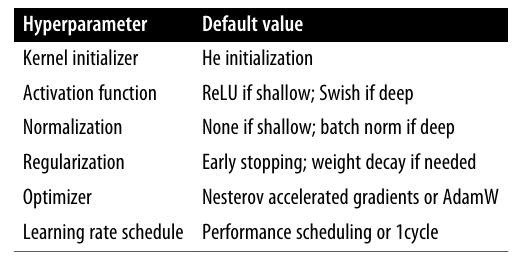

### Configuración de una red profunda, que es una pila de capas densas (self-normalize)

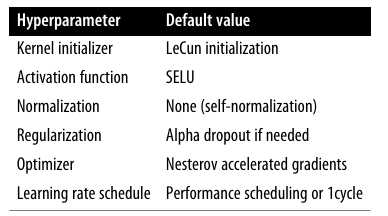

###